In [1]:
import kagglehub
import pandas as pd
import numpy as np

path = kagglehub.competition_download('ieee-fraud-detection')
train = pd.read_csv(f'{path}/train_transaction.csv', index_col='TransactionID')
print(f'Shape: {train.shape}')
print(f'Fraud rate: {train["isFraud"].mean() * 100:.2f}%')

/Users/cjan/golark/frauddetection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (590540, 393)
Fraud rate: 3.50%


In [2]:
features = [
    'TransactionAmt', 'ProductCD',
    'card1', 'card2', 'card3', 'card5',
    'addr1', 'addr2', 'dist1',
    'P_emaildomain', 'R_emaildomain',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
]

X = train[features].copy()
y = train['isFraud'].copy()
print(f'X shape: {X.shape}')

X shape: (590540, 49)


In [3]:
cat_cols = X.select_dtypes('object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Categorical columns (12): ['ProductCD', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


/var/folders/x3/8p7z80zn1196wjdll1mkmytc0000gn/T/ipykernel_4992/2924465825.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes('object').columns.tolist()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = X_train[col].fillna('MISSING').astype(str)
    X_test[col] = X_test[col].fillna('MISSING').astype(str)
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

num_cols = X.select_dtypes(exclude='object').columns
for col in num_cols:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_train[col].median())

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Test fraud rate: {y_test.mean() * 100:.2f}%')

Train: (472432, 49), Test: (118108, 49)
Test fraud rate: 3.50%


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, classification_report
)
import time

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42,
)

t0 = time.time()
rf.fit(X_train, y_train)
t_train = time.time() - t0

t0 = time.time()
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
t_infer = time.time() - t0

pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Train time: {t_train:.1f}s')
print(f'Inference time (50k rows): {t_infer:.3f}s')
print(f'PR-AUC: {pr_auc:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

Train time: 50.2s
Inference time (50k rows): 1.728s
PR-AUC: 0.5645
ROC-AUC: 0.9115

              precision    recall  f1-score   support

       Legit       0.99      0.89      0.94    113975
       Fraud       0.21      0.77      0.32      4133

    accuracy                           0.89    118108
   macro avg       0.60      0.83      0.63    118108
weighted avg       0.96      0.89      0.92    118108



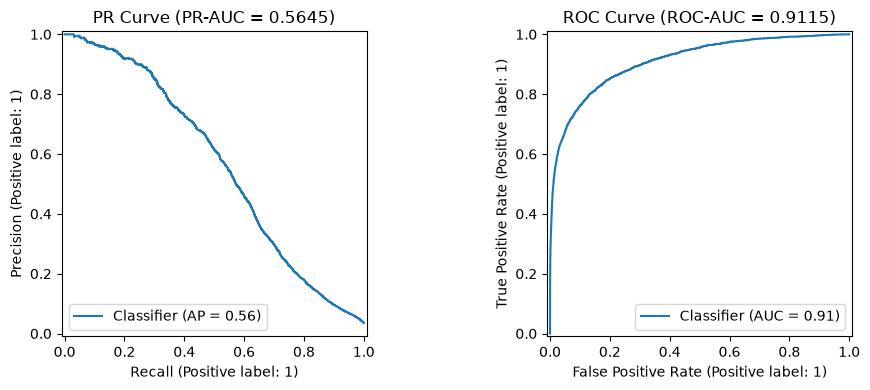

In [6]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax1)
ax1.set_title(f'PR Curve (PR-AUC = {pr_auc:.4f})')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2)
ax2.set_title(f'ROC Curve (ROC-AUC = {roc_auc:.4f})')

plt.tight_layout()
plt.show()

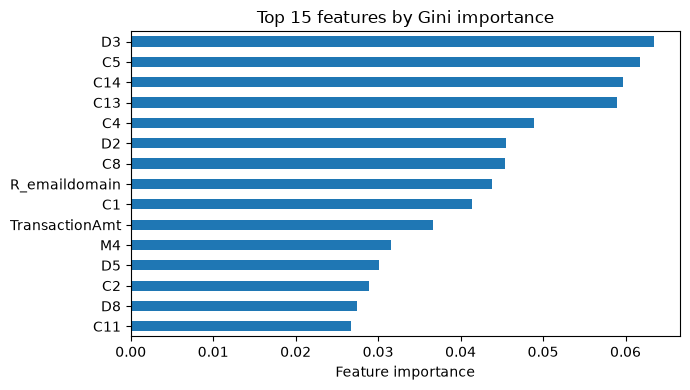

In [7]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 4))
top15.sort_values().plot.barh(ax=ax)
ax.set_xlabel('Feature importance')
ax.set_title('Top 15 features by Gini importance')
plt.tight_layout()
plt.show()